# **Experiment 3**

In [1]:
# Do not modify this code
!pip install -q utstd imbalanced-learn xgboost

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

In [3]:
import pandas as pd

pd.__version__

'2.2.2'

---
## Student Information

In [4]:
# <Student to fill this section>
student_name = "Ratnadeep Patra"
student_id = "26294153"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

In [7]:
import adv_ml_at2 as at2
import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from adv_ml_at2.modeling.custom_models import make_smote_classifier
from sklearn.base import clone
from sklearn.metrics import f1_score, make_scorer, recall_score, confusion_matrix
import adv_ml_at2.modeling.custom_models as custom_models_module

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("max_colwidth", None)

---
## A. Project Description

In [8]:
forecast_horizons_days = 7

business_use_case_description = f"""
The business use case is {forecast_horizons_days}-day-ahead weather hazard forecasting for Sydney, with particular emphasis on identifying potentially dangerous conditions before they occur. The Weather Hazard Category combines 
precipitation, wind gusts, cloud cover, snowfall and temperature into four interpretable levels: Low Risk, Moderate Risk, High Risk and Extreme Risk. Historical weather observations are used to predict the expected hazard category 
exactly {forecast_horizons_days} days ahead so organisations can identify periods that may require additional preparation without having to interpret several weather variables independently. This type of early indication can support 
transport planning, outdoor events, workforce scheduling, infrastructure preparation and other activities that may be affected by hazardous weather. Particular attention is given to High Risk and Extreme Risk conditions because 
these less common events may require more preparation and can have greater operational consequences if they are not identified early. The model is intended to support early planning and monitoring rather than act as an automatic 
warning or cancellation system.
"""

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
business_objectives = """
The main business objective is to provide organisations with enough advance warning to recognise periods where weather conditions may create greater operational risk. A useful prediction should allow stakeholders to distinguish 
between normal conditions that require little additional preparation and more hazardous conditions where contingency planning, additional monitoring or changes to normal operations may be appropriate. The consequences of different 
prediction errors are not equal. If a genuinely High Risk or Extreme Risk day is predicted as Low or Moderate Risk, organisations may underestimate the expected conditions and fail to prepare sufficiently. This can be more costly 
than incorrectly identifying a lower-risk day as more hazardous, where the likely consequence is additional monitoring or precautionary preparation that may later prove unnecessary. For this reason, particular importance is placed 
on avoiding missed High Risk and Extreme Risk conditions. At the same time, the model should not repeatedly generate unnecessarily severe predictions, as frequent false alarms could lead to avoidable operational costs and reduce 
confidence in the service. The desired outcome is therefore a useful balance where hazardous conditions are identified consistently enough to support early preparation while the predictions remain practical for routine planning.
"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
stakeholders_expectations_explanations = f"""
Stakeholders using the service would expect a clear and understandable indication of weather risk {forecast_horizons_days} days in advance so that they have time to review upcoming operations and prepare where necessary. Rather 
than requiring users to interpret individual forecasts for rainfall, wind, cloud cover, snowfall and temperature, the Weather Hazard Category provides a single risk level that can be incorporated more easily into planning decisions. 
The service is also designed to make access to the prediction simple. Users only need to provide the date for which the forecast is required through a single API endpoint. The service internally retrieves the required weather 
information, prepares the relevant inputs and returns the predicted Weather Hazard Category. This removes the need for organisations using the service to separately collect, combine or process multiple weather variables and makes 
the forecasting capability easier to integrate into existing operational systems. For routine Low Risk or Moderate Risk predictions, stakeholders may continue normal planning while monitoring updated weather information. A High 
Risk prediction may justify closer monitoring, preparation of contingency plans or adjustments to weather-sensitive activities. An Extreme Risk prediction would warrant greater attention because failing to recognise such conditions 
early could have more serious operational consequences. Stakeholders would therefore expect the system to be particularly dependable when identifying the higher-risk categories. However, the prediction should still be treated as 
an early planning signal rather than a final operational decision. As the forecast date approaches, organisations can combine the model output with newer weather information and their own operational requirements before deciding 
whether any action is necessary.
"""

In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

> Hypothesis: Non-linear tree ensembles will improve WHC class separation by capturing relationships that linear Logistic Regression cannot. Random Forest tests bagging across many trees, while XGBoost progressively reduces previous errors. Both are evaluated for improved hazardous-risk recall while maintaining a reasonable macro F1 balance.


---
## C. Data Understanding

### C.1 Load Raw Data

In [14]:
hourly_weather_df = pd.read_csv(at2.dataset.RAW_DATA_DIR / "sydney_weather_hourly.csv", parse_dates=["time"])
daily_weather_df = pd.read_csv(at2.dataset.RAW_DATA_DIR / "sydney_weather_daily.csv", parse_dates=["time"])
aggregation_rules = {
    "temperature_2m": ["mean", "max", "min", "median"],
    "relative_humidity_2m": ["mean", "max", "min", "median"],
    "wind_speed_10m": ["mean", "max"],
    "wind_speed_100m": ["mean", "max"],
    "wind_gusts_10m": ["mean", "max"],
    "cloud_cover": ["mean", "max"],
    "cloud_cover_low": ["mean", "max"],
    "cloud_cover_mid": ["mean", "max"],
    "cloud_cover_high": ["mean", "max"],
    "precipitation": ["sum", "max"],
    "snowfall": ["sum"],
    "pressure_msl": ["mean", "max", "min"],
    "dew_point_2m": ["mean", "max", "min"],
    "vapour_pressure_deficit": ["mean", "max"],
    "soil_moisture_0_to_7cm": ["mean"],
    "apparent_temperature": ["mean", "max", "min"],
    "shortwave_radiation": ["mean", "max"],
    "sunshine_duration": ["sum"]
}
daily_features_df = at2.dataset.build_daily_weather_dataset(hourly_weather_df=hourly_weather_df, daily_weather_df=daily_weather_df, aggregation_rules=aggregation_rules)
print("Daily weather shape:", daily_features_df.shape)

Daily weather shape: (9497, 44)


### C.2 Define Target variable

In [15]:
target_name = f"whc_target_{forecast_horizons_days}d"
target_label_name = f"whc_label_target_{forecast_horizons_days}d"

whc_class_definitions = pd.DataFrame([
    {"WHI condition": "WHI < 25", "WHC class": 0, "WHC label": "Low Risk"},
    {"WHI condition": "25 <= WHI < 50", "WHC class": 1, "WHC label": "Moderate Risk"},
    {"WHI condition": "50 <= WHI < 75", "WHC class": 2, "WHC label": "High Risk"},
    {"WHI condition": "WHI >= 75", "WHC class": 3, "WHC label": "Extreme Risk"}
])
display(whc_class_definitions)

,WHI condition,WHC class,WHC label
0,WHI < 25,0,Low Risk
1,25 <= WHI < 50,1,Moderate Risk
2,50 <= WHI < 75,2,High Risk
3,WHI >= 75,3,Extreme Risk


In [16]:
target_definition_explanations = f"""
The target definition is unchanged from the previous experiments. WHC is predicted {forecast_horizons_days} days ahead using the same four ordered risk categories and the same leakage-safe lagged predictor space.
"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [18]:
daily_whi_df = at2.features.aggregate_daily_whi(hourly_weather_df)
hazard_columns = ["rain_hazard", "wind_hazard", "cloud_hazard", "snow_hazard", "temperature_hazard", "whi", "whc", "whc_label"]

weather_df = daily_features_df.merge(daily_whi_df[["time"] + hazard_columns], on="time", how="inner", validate="one_to_one")
weather_df = at2.features.create_whc_forecast_targets(weather_df, horizon=forecast_horizons_days)
weather_df = at2.features.lag_feature_space(weather_df, target_columns=[target_name, target_label_name], lag_days=1)
weather_df = weather_df.dropna(subset=[target_name]).reset_index(drop=True)
weather_df[target_name] = weather_df[target_name].astype("int64")
print(f"Final supervised rows: {len(weather_df):,}")

Final supervised rows: 9,489


### C.4 Explore Target variable

In [19]:
target_distribution = weather_df[target_name].value_counts().sort_index().rename("count").to_frame()
target_distribution["label"] = target_distribution.index.map(at2.features.WHC_LABELS)
target_distribution["proportion"] = target_distribution["count"] / target_distribution["count"].sum()
display(target_distribution[["label", "count", "proportion"]].round(4))

,label,count,proportion
whc_target_7d,,,
0,Low Risk,5239,0.5521
1,Moderate Risk,3965,0.4179
2,High Risk,274,0.0289
3,Extreme Risk,11,0.0012


In [20]:
target_distribution_explanations = """
Low and Moderate Risk remain the dominant categories, while High Risk is uncommon and Extreme Risk is extremely rare. Proportion-aware SMOTE is therefore used during model fitting to increase minority representation without forcing
every class directly to the majority size.
"""

In [21]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Model Features

In [22]:
feature_1_insights = """
Experiment 3 reuses the earlier feature understanding but does not restrict the tree models to the compact predictor subset used by Logistic Regression. Valid lagged weather features are retained even when their individual linear
association is weak, allowing Random Forest and XGBoost to determine which variables, thresholds and interactions are useful through their split structure.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

---
## D. Feature Selection

### D.1 Approach "Keep Broader Lagged Feature Space"


In [24]:
feature_selection_1_insights = """
Experiment 3 removes the explicit 'retain_selected_features' step used in Experiments 1 and 2. The linear models benefited from a compact selected feature set, whereas tree ensembles can choose useful predictors directly through
their split structure. The broader leakage-safe lagged feature space is therefore retained so Random Forest and XGBoost can determine which variables and interactions contribute useful separation.
"""

In [25]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

---
## E. Data Preparation

### E.1 Data Transformation "Reuse Saved Preprocessing"


In [26]:
experiment_1_path = at2.config.MODELS_DIR / "weather_hazard" / "experiment_1" / "experiment_1.pkl"
with experiment_1_path.open("rb") as file:
    experiment_1_artifact = cloudpickle.load(file)
experiment_1_ml_workflow = experiment_1_artifact["ml_workflow"]
reference_preprocessing = getattr(experiment_1_ml_workflow, "preprocessing_", experiment_1_ml_workflow.preprocessing)
experiment_3_preprocessing = clone(reference_preprocessing).exclude_steps(["retain_selected_features"])
print("Removed preprocessing step: retain_selected_features")
print("Reused preprocessing steps:", [name for name, step in experiment_3_preprocessing.steps if step != "passthrough"])

Removed preprocessing step: retain_selected_features
Reused preprocessing steps: ['remove_non_model_labels', 'add_log1p_precipitation', 'add_annual_cycle_features', 'add_wind_direction_features', 'add_selected_whi_history', 'retain_complete_temporal_context', 'add_selected_interactions', 'temporal_train_validation_test_split', 'standardise_model_matrix']


In [27]:
data_transformation_1_explanations = """
Experiment 3 reuses the saved preprocessing pipeline but removes the explicit feature-selection step so the tree ensembles receive the broader leakage-safe lagged feature space. Existing engineered temporal, cyclic, WHI-history
and interaction features are retained together with the same chronological split. Unlike the regression tree experiment, training-fitted standardisation is retained here because SMOTE constructs synthetic observations using 
nearest-neighbour distances. Keeping predictors on comparable scales prevents large-scale variables from dominating the SMOTE neighbourhood calculation, even though Random Forest and XGBoost themselves do not require standardised 
inputs.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## F. Feature Engineering

### F.1 New Feature "Reuse Existing Engineered Features"


In [29]:
feature_engineering_seasonality_explanations = """
No new engineered predictors are introduced in Experiment 3. The existing temporal, cyclic, WHI-history and selected interaction features are reused alongside the broader lagged weather feature space, allowing the tree ensembles
to decide which raw and engineered predictors provide useful separation.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_seasonality_explanations', value=feature_engineering_seasonality_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [31]:
X_train, X_val, X_test = experiment_3_preprocessing.fit_transform(weather_df)
y_train, y_val, y_test = experiment_3_preprocessing.multiplex_y_

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "proportion": np.array([len(X_train), len(X_val), len(X_test)]) / (len(X_train) + len(X_val) + len(X_test))
}, index=["train", "validation", "test"])

display(split_summary)
display(pd.concat({"train": y_train.value_counts(normalize=True).sort_index(), "validation": y_val.value_counts(normalize=True).sort_index(), "test": y_test.value_counts(normalize=True).sort_index()}, 
                  axis=1).fillna(0).round(4))

,rows,proportion
train,8006,0.846300
validation,730,0.077167
test,724,0.076533


,train,validation,test
whc_target_7d,,,
0,0.5697,0.4836,0.4309
1,0.4039,0.4671,0.5180
2,0.0254,0.0466,0.0497
3,0.0010,0.0027,0.0014


In [32]:
data_splitting_explanations = """
The same chronological train, validation and test partitions are reused so Experiment 3 remains directly comparable with the previous classification experiments. Model selection is based on validation performance and the test
partition remains reserved for final evaluation.
"""

In [33]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Training-Fitted Standardisation for SMOTE"


In [34]:
data_transformation_3_explanations = """
Training-fitted standardisation is retained because proportion-aware SMOTE uses nearest-neighbour distances when creating synthetic minority observations. Scaling is learned only from the training partition and reused for validation
and test, while SMOTE itself is applied only during model fitting so validation and test class distributions remain unchanged.
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

In [36]:
data_final_path = at2.config.PROCESSED_DATA_DIR / "weather_hazard" / "experiment_3"
data_final_path.mkdir(parents=True, exist_ok=True)

In [37]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(f'{data_final_path}/X_train.csv', index=False)
  y_train.to_csv(f'{data_final_path}/y_train.csv', index=False)

  X_val.to_csv(f'{data_final_path}/X_val.csv', index=False)
  y_val.to_csv(f'{data_final_path}/y_val.csv', index=False)

  X_test.to_csv(f'{data_final_path}/X_test.csv', index=False)
  y_test.to_csv(f'{data_final_path}/y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

In [38]:
class_ids = sorted(at2.features.WHC_LABELS)
high_group_ids = class_ids[2:]
severity_weights = np.array([1.0, 1.0, 1.5, 1.5])

def severity_weighted_recall(y_true, y_pred):
    recalls = recall_score(y_true, y_pred, labels=class_ids, average=None, zero_division=0)
    return np.average(recalls, weights=severity_weights)

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=class_ids, average="macro", zero_division=0)

primary_metric = "severity_weighted_recall"
secondary_metric = "macro_f1"
classification_scorer = make_scorer(severity_weighted_recall)

In [39]:
performance_metrics_explanations = f"""
Experiment 3 retains {primary_metric} as the primary metric so the tree models remain directly comparable with Experiments 1 and 2. Recall is calculated across all four WHC classes using severity weights of {severity_weights.tolist()}, 
while macro F1 is retained as the secondary metric to track the overall precision-recall balance. The tree models are therefore compared primarily on hazardous-risk sensitivity, with macro F1 used to check that a recall improvement 
is not obtained through a disproportionate increase in false-positive predictions.
"""

In [40]:
# Do not modify this code
print_tile(size="h3", key="performance_metrics_explanations", value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

In [41]:
import optuna

from mlweave.workflow.workflow import MLWorkflow
from mlweave.workflow.decorators.step import inference_step
from optuna.integration import OptunaSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [42]:
algorithm_selection_explanations = """
Experiment 3 compares Random Forest and XGBoost because both can capture non-linear, threshold-dependent relationships and feature interactions that may not be represented well by the linear Logistic Regression used previously. 
Random Forest is selected as a bagging-based ensemble that fits many decision trees independently on perturbed samples and combines their predictions, providing a robust test of whether averaging diverse decision boundaries 
improves class separation. XGBoost is selected as a boosting-based ensemble that builds trees sequentially, with each new tree focused on correcting errors from the existing ensemble, testing whether progressive error correction 
better captures difficult classification patterns. Using these two complementary ensemble strategies allows the experiment to compare independent tree averaging against sequential error correction under the same proportion-aware 
SMOTE treatment, while keeping minority-class representation consistent across both models.
"""

In [43]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

In [44]:
sampling_multiplier = 10
k_neighbors = 7

random_forest_params = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_leaf": 2,
    "n_jobs": -1,
    "random_state": 42
}

xgboost_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 4,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "n_jobs": -1,
    "random_state": 42
}

In [45]:
hyperparameters_selection_explanations = """
Experiment 3 starts with compact configurations for both Random Forest and XGBoost together with proportion-aware SMOTE. The sampling_multiplier controls how strongly the minority High and Extreme Risk classes are oversampled, 
while k_neighbors controls how many neighbouring minority observations are used when constructing synthetic samples. For XGBoost, n_estimators controls the number of sequential boosting trees, learning_rate controls how strongly 
each new tree contributes to the ensemble, and max_depth limits the complexity of individual trees. Subsample controls the proportion of training observations used for each boosting stage, while colsample_bytree controls the 
proportion of predictors available to each tree. These sampling parameters provide additional regularisation while still allowing the model to capture nonlinear thresholds and feature interactions. For Random Forest, n_estimators 
controls the number of independently trained trees whose predictions are combined, max_depth limits the complexity of each tree, and min_samples_leaf controls the minimum number of observations required in a terminal leaf. These 
parameters balance the ability to capture nonlinear class boundaries against the risk of creating overly specific trees that do not generalise well.
"""

In [46]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [47]:
def test_model(model, sampling_multiplier, k_neighbors):
    fitted_model = make_smote_classifier(model, sampling_multiplier=sampling_multiplier, k_neighbors=k_neighbors, random_state=42)
    fitted_model.fit(X_train, y_train)
    train_pred = fitted_model.predict(X_train)
    val_pred = fitted_model.predict(X_val)
    return {
        "sampling_multiplier": sampling_multiplier,
        "k_neighbors": k_neighbors,
        f"train_{primary_metric}": severity_weighted_recall(y_train, train_pred),
        f"val_{primary_metric}": severity_weighted_recall(y_val, val_pred),
        f"train_{secondary_metric}": macro_f1(y_train, train_pred),
        f"val_{secondary_metric}": macro_f1(y_val, val_pred)
    }

#### J.3.1 Random Forest

In [48]:
sampling_multipliers = [1, 5, 10, 15, 20]
k_neighbors_values = [1, 3, 5, 7]
rf_smote_results = pd.DataFrame([
    test_model(RandomForestClassifier(**random_forest_params), sampling_multiplier=multiplier, k_neighbors=k)
    for multiplier in sampling_multipliers for k in k_neighbors_values])
rf_smote_results["primary_gap"] = rf_smote_results[f"train_{primary_metric}"] - rf_smote_results[f"val_{primary_metric}"]

print(f"Val_{primary_metric}:")
display(rf_smote_results.pivot(index="sampling_multiplier", columns="k_neighbors", values=f"val_{primary_metric}").round(4))
print(f"Val_{secondary_metric}:")
display(rf_smote_results.pivot(index="sampling_multiplier", columns="k_neighbors", values=f"val_{secondary_metric}").round(4))
print(f"Primary_gap:")
display(rf_smote_results.pivot(index="sampling_multiplier", columns="k_neighbors", values=f"primary_gap").round(4))

Val_severity_weighted_recall:


k_neighbors,1,3,5,7
sampling_multiplier,,,,
1,0.2178,0.2178,0.2178,0.2178
5,0.2215,0.2180,0.2221,0.2175
10,0.2274,0.2163,0.2246,0.2275
15,0.2217,0.2277,0.2347,0.2306
20,0.2206,0.2313,0.2389,0.2424


Val_macro_f1:


k_neighbors,1,3,5,7
sampling_multiplier,,,,
1,0.2591,0.2591,0.2591,0.2591
5,0.2694,0.2651,0.2703,0.2646
10,0.2791,0.2650,0.2754,0.2793
15,0.2719,0.2765,0.2804,0.2752
20,0.2675,0.2696,0.2721,0.2765


Primary_gap:


k_neighbors,1,3,5,7
sampling_multiplier,,,,
1,0.0747,0.0747,0.0747,0.0747
5,0.1083,0.1085,0.0983,0.0916
10,0.2200,0.1937,0.1920,0.1806
15,0.3220,0.3003,0.3105,0.2737
20,0.3639,0.4080,0.3735,0.3255


In [49]:
depth_values = [2, 3, 4, 5, 6, 8]
leaf_values = [1, 2, 5, 10, 20]
rf_complexity_results = pd.DataFrame([{**test_model(RandomForestClassifier(**{**random_forest_params, "max_depth": depth, "min_samples_leaf": leaf}),
            sampling_multiplier=5, k_neighbors=5), "max_depth": depth, "min_samples_leaf": leaf}
    for depth in depth_values for leaf in leaf_values])
rf_complexity_results["primary_gap"] = rf_complexity_results[f"train_{primary_metric}"] - rf_complexity_results[f"val_{primary_metric}"]

print(f"Val_{primary_metric}:")
display(rf_complexity_results.pivot(index="max_depth", columns="min_samples_leaf", values=f"val_{primary_metric}").round(4))
print(f"Val_{secondary_metric}:")
display(rf_complexity_results.pivot(index="max_depth", columns="min_samples_leaf", values=f"val_{secondary_metric}").round(4))
print(f"Primary_gap:")
display(rf_complexity_results.pivot(index="max_depth", columns="min_samples_leaf", values="primary_gap").round(4))

Val_severity_weighted_recall:


min_samples_leaf,1,2,5,10,20
max_depth,,,,,
2,0.2217,0.2217,0.2217,0.2217,0.2217
3,0.2182,0.2182,0.2182,0.2188,0.2182
4,0.2182,0.2182,0.2182,0.2182,0.2176
5,0.2176,0.2182,0.2182,0.2188,0.2194
6,0.2187,0.2181,0.2170,0.2182,0.2176
8,0.2210,0.2221,0.2204,0.2198,0.2169


Val_macro_f1:


min_samples_leaf,1,2,5,10,20
max_depth,,,,,
2,0.2701,0.2701,0.2701,0.2701,0.2701
3,0.2658,0.2658,0.2658,0.2664,0.2658
4,0.2657,0.2657,0.2657,0.2657,0.2650
5,0.2650,0.2657,0.2657,0.2664,0.2671
6,0.2663,0.2655,0.2641,0.2656,0.2649
8,0.2688,0.2703,0.2682,0.2674,0.2638


Primary_gap:


min_samples_leaf,1,2,5,10,20
max_depth,,,,,
2,0.0179,0.0179,0.0179,0.0179,0.0179
3,0.0225,0.0225,0.0225,0.0219,0.0225
4,0.0231,0.0232,0.0231,0.0230,0.0237
5,0.0270,0.0262,0.0259,0.0254,0.0243
6,0.0371,0.0365,0.0355,0.0337,0.0322
8,0.1425,0.0983,0.0902,0.0767,0.0600


In [50]:
n_estimators_values = [50, 100, 200, 300, 500, 750]
rf_estimators_results = pd.DataFrame([{**test_model(RandomForestClassifier(**{**random_forest_params, "n_estimators": n_estimators, "max_depth": 2, "min_samples_leaf": 2}),
            sampling_multiplier=5, k_neighbors=5), "n_estimators": n_estimators}
    for n_estimators in n_estimators_values])
rf_estimators_results["primary_gap"] = rf_estimators_results[f"train_{primary_metric}"] - rf_estimators_results[f"val_{primary_metric}"]

display(rf_estimators_results[["n_estimators", f"train_{primary_metric}", f"val_{primary_metric}", f"val_{secondary_metric}", "primary_gap"]].round(4))

,n_estimators,train_severity_weighted_recall,val_severity_weighted_recall,val_macro_f1,primary_gap
0,50,0.2402,0.2194,0.2672,0.0208
1,100,0.2397,0.2205,0.2686,0.0191
2,200,0.2398,0.2211,0.2694,0.0187
3,300,0.2396,0.2217,0.2701,0.0179
4,500,0.2400,0.2212,0.2694,0.0188
5,750,0.2397,0.2217,0.2701,0.0180


#### J.3.2 XGBoost

In [51]:
sampling_multipliers = [1, 5, 10, 15, 20]
k_neighbors_values = [1, 3, 5, 7]
xgb_smote_results = pd.DataFrame([test_model(XGBClassifier(**xgboost_params), sampling_multiplier=multiplier, k_neighbors=k)
    for multiplier in sampling_multipliers for k in k_neighbors_values])
xgb_smote_results["primary_gap"] = xgb_smote_results[f"train_{primary_metric}"] - xgb_smote_results[f"val_{primary_metric}"]

print(f"Val_{primary_metric}:")
display(xgb_smote_results.pivot(index="sampling_multiplier", columns="k_neighbors", values=f"val_{primary_metric}").round(4))
print(f"Val_{secondary_metric}:")
display(xgb_smote_results.pivot(index="sampling_multiplier", columns="k_neighbors", values=f"val_{secondary_metric}").round(4))
print(f"Primary_gap:")
display(xgb_smote_results.pivot(index="sampling_multiplier", columns="k_neighbors", values="primary_gap").round(4))

Val_severity_weighted_recall:


k_neighbors,1,3,5,7
sampling_multiplier,,,,
1,0.2135,0.2135,0.2135,0.2135
5,0.2079,0.2073,0.2158,0.2026
10,0.2077,0.2020,0.2106,0.2095
15,0.2101,0.2059,0.2101,0.2043
20,0.2050,0.1989,0.2015,0.2085


Val_macro_f1:


k_neighbors,1,3,5,7
sampling_multiplier,,,,
1,0.2562,0.2562,0.2562,0.2562
5,0.2538,0.2531,0.2630,0.2471
10,0.2550,0.2482,0.2589,0.2567
15,0.2588,0.2557,0.2617,0.2536
20,0.2557,0.2484,0.2530,0.2562


Primary_gap:


k_neighbors,1,3,5,7
sampling_multiplier,,,,
1,0.4584,0.4584,0.4584,0.4584
5,0.5098,0.5003,0.5002,0.4813
10,0.5514,0.5704,0.5546,0.5438
15,0.5743,0.6076,0.5955,0.5948
20,0.5984,0.6199,0.6306,0.6096


In [52]:
xgb_regularised_result = pd.DataFrame([{**test_model(XGBClassifier(**{**xgboost_params, "max_depth": 1, "learning_rate": 0.05}),
            sampling_multiplier=5, k_neighbors=5), "max_depth": 1, "learning_rate": 0.05}])
xgb_regularised_result["primary_gap"] = xgb_regularised_result[f"train_{primary_metric}"] - xgb_regularised_result[f"val_{primary_metric}"]
display(xgb_regularised_result[["max_depth", "learning_rate", f"train_{primary_metric}", f"val_{primary_metric}", f"val_{secondary_metric}", "primary_gap"]].round(4))

,max_depth,learning_rate,train_severity_weighted_recall,val_severity_weighted_recall,val_macro_f1,primary_gap
0,1,0.05,0.241,0.2171,0.2644,0.0239


In [53]:
xgb_depth_lr_results = pd.DataFrame([{**test_model(XGBClassifier(**{**xgboost_params, "max_depth": depth, "learning_rate": learning_rate}),
            sampling_multiplier=5, k_neighbors=5), "max_depth": depth, "learning_rate": learning_rate}
    for depth in [1, 2] for learning_rate in [0.01, 0.03, 0.05, 0.1]])
print(f"Val_{primary_metric}:")
xgb_depth_lr_results["primary_gap"] = xgb_depth_lr_results[f"train_{primary_metric}"] - xgb_depth_lr_results[f"val_{primary_metric}"]
display(xgb_depth_lr_results.pivot(index="max_depth", columns="learning_rate", values=f"val_{primary_metric}").round(4))
print(f"Val_{secondary_metric}:")
display(xgb_depth_lr_results.pivot(index="max_depth", columns="learning_rate", values=f"val_{secondary_metric}").round(4))
print(f"Primary_gap:")
display(xgb_depth_lr_results.pivot( index="max_depth", columns="learning_rate", values="primary_gap").round(4))

Val_severity_weighted_recall:


learning_rate,0.01,0.03,0.05,0.10
max_depth,,,,
1,0.2159,0.2164,0.2171,0.2201
2,0.2158,0.2187,0.2280,0.2200


Val_macro_f1:


learning_rate,0.01,0.03,0.05,0.10
max_depth,,,,
1,0.2628,0.2635,0.2644,0.2682
2,0.2625,0.2660,0.2780,0.2685


Primary_gap:


learning_rate,0.01,0.03,0.05,0.10
max_depth,,,,
1,0.0237,0.0240,0.0239,0.0988
2,0.0249,0.1393,0.2199,0.3237


In [54]:
rf_search_space = {
    "sampling_multiplier": optuna.distributions.FloatDistribution(3.0, 10.0),
    "k_neighbors": optuna.distributions.IntDistribution(1, 7),
    "estimator__n_estimators": optuna.distributions.IntDistribution(150, 500),
    "estimator__max_depth": optuna.distributions.IntDistribution(2, 5),
    "estimator__min_samples_leaf": optuna.distributions.IntDistribution(1, 10),
}

@inference_step
def evaluate_classification(context):
    predictions = context.model.predict(context.X_test)
    return {
        primary_metric: severity_weighted_recall(context.y_test, predictions),
        secondary_metric: macro_f1(context.y_test, predictions)
    }

rf_search = OptunaSearchCV(
    estimator=make_smote_classifier(RandomForestClassifier(n_jobs=-1, random_state=42), random_state=42),
    param_distributions=rf_search_space, n_trials=40, scoring=classification_scorer, refit=True, return_train_score=True, random_state=42
)

ml_workflow = MLWorkflow(preprocessing=experiment_3_preprocessing, model_search=rf_search, inference=evaluate_classification())

In [55]:
ml_workflow.run(weather_df, track=False)

X_train, X_val, X_test = ml_workflow.X_parts_
y_train, y_val, y_test = ml_workflow.y_parts_
tuned_xgboost_model = ml_workflow.model_

train_pred = tuned_xgboost_model.predict(X_train)
val_pred = tuned_xgboost_model.predict(X_val)

best_model_results = pd.DataFrame([{
    **ml_workflow.best_params_,
    "training_rows": sum(tuned_xgboost_model.class_counts_after_.values()),
    f"train_{primary_metric}": severity_weighted_recall(y_train, train_pred),
    f"val_{primary_metric}": severity_weighted_recall(y_val, val_pred),
    f"train_{secondary_metric}": macro_f1(y_train, train_pred),
    f"val_{secondary_metric}": macro_f1(y_val, val_pred)
}])

display(best_model_results.round(4))

,sampling_multiplier,k_neighbors,estimator__n_estimators,estimator__max_depth,estimator__min_samples_leaf,training_rows,train_severity_weighted_recall,val_severity_weighted_recall,train_macro_f1,val_macro_f1
0,7.7272,6,247,2,10,10692,0.2389,0.2235,0.2932,0.2722


### J.4 Model Technical Performance

In [56]:
final_model = tuned_xgboost_model
partitions = {
    "Training": (X_train, y_train),
    "Validation": (X_val, y_val),
    "Test": (X_test, y_test)
}

technical_performance = pd.DataFrame([
    {
        "partition": name,
        primary_metric: severity_weighted_recall(y, final_model.predict(X)),
        secondary_metric: macro_f1(y, final_model.predict(X))
    }
    for name, (X, y) in partitions.items()
]).set_index("partition")

display(technical_performance.round(4))


,severity_weighted_recall,macro_f1
partition,,
Training,0.2389,0.2932
Validation,0.2235,0.2722
Test,0.2281,0.2768


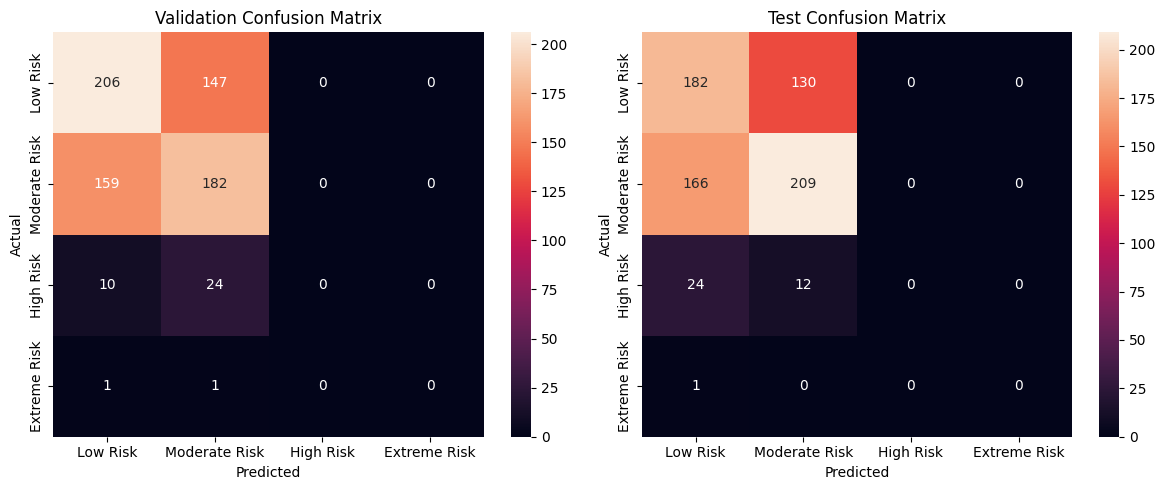

In [57]:
validation_predictions = final_model.predict(X_val)
test_predictions = final_model.predict(X_test)
class_names = [at2.features.WHC_LABELS[class_id] for class_id in class_ids]

figure, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, predictions, actual, title in [
    (axes[0], validation_predictions, y_val, "Validation Confusion Matrix"),
    (axes[1], test_predictions, y_test, "Test Confusion Matrix")
]:
    matrix = confusion_matrix(actual, predictions, labels=class_ids)
    sns.heatmap(matrix, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=title, xlabel="Predicted", ylabel="Actual")
figure.tight_layout()

In [59]:
selected_model_name = "Random Forest"
train_primary = technical_performance.loc["Training", primary_metric]
val_primary = technical_performance.loc["Validation", primary_metric]
test_primary = technical_performance.loc["Test", primary_metric]
generalisation_gap = train_primary - val_primary
test_class_recalls = dict(zip(class_names, recall_score(y_test, test_predictions, labels=class_ids, average=None, zero_division=0)))

model_performance_explanations = f"""
The tuned SMOTE + {selected_model_name} model has a small training-validation {primary_metric} gap of {generalisation_gap:.4f}, while validation and test performance are also similar ({val_primary:.4f} and {test_primary:.4f}). 
This indicates that restricting tree complexity successfully controlled the strong overfitting observed with deeper ensemble models. Manual SMOTE testing also showed that further increasing the sampling multiplier, and therefore 
generating more synthetic minority samples, progressively increased the training-validation gap without producing a comparable improvement in validation performance. More aggressive oversampling was therefore not considered a 
reliable solution to the rare-class problem, as it encouraged the model to fit the synthetic training distribution more strongly rather than improving generalisation. However, the confusion matrices reveal a more important limitation 
than the aggregate scores alone. On the held-out test period, High Risk recall is {test_class_recalls["High Risk"]:.2%} and Extreme Risk recall is  {test_class_recalls["Extreme Risk"]:.2%}. The model therefore generalises consistently, 
but mainly by separating the much more common Low and Moderate Risk classes rather than identifying hazardous conditions. This is important  because a non-zero severity-weighted recall does not by itself guarantee useful hazardous 
event detection. Low and Moderate Risk recall also contribute to the weighted average, so the class-level results must be considered alongside the aggregate metric when judging whether the model satisfies the business objective.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key="model_performance_explanations", value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

In [61]:
business_impact = pd.DataFrame([
    {
        "partition": partition,
        "actual_high_risk_events": actual.sum(),
        "predicted_high_risk_alerts": predicted.sum(),
        "caught_high_risk_events": (actual & predicted).sum(),
        "missed_high_risk_events": (actual & ~predicted).sum(),
        "false_high_risk_alerts": (~actual & predicted).sum(),
        "high_risk_recall": (actual & predicted).sum() / actual.sum(),
        "high_risk_alert_precision": (actual & predicted).sum() / predicted.sum() if predicted.sum() else np.nan
    }
    for partition, y, predictions in [("Validation", y_val, validation_predictions), ("Test", y_test, test_predictions)]
    for actual, predicted in [(np.isin(y, high_group_ids), np.isin(predictions, high_group_ids))]
]).set_index("partition")
display(business_impact.round(4))

,actual_high_risk_events,predicted_high_risk_alerts,caught_high_risk_events,missed_high_risk_events,false_high_risk_alerts,high_risk_recall,high_risk_alert_precision
partition,,,,,,,
Validation,36,0,0,36,0,0.0,NaN
Test,37,0,0,37,0,0.0,NaN


In [62]:
test_business = business_impact.loc["Test"]

business_impacts_explanations = f"""
The held-out test period contains {int(test_business["actual_high_risk_events"])} actual High or Extreme Risk events. The model identifies {int(test_business["caught_high_risk_events"])} and misses {int(test_business["missed_high_risk_events"])}, 
giving a combined hazardous-event recall of {test_business["high_risk_recall"]:.2%}. For the intended business use case, this is a critical limitation. Missing hazardous days means organisations relying on the model would not 
receive an early signal to increase monitoring, prepare contingency plans or review weather-sensitive operations. Stable aggregate validation and test scores therefore do not translate into useful performance for the events that 
motivated the forecasting service. The absence of false alerts should not be interpreted as strong alert precision. No hazardous alerts were generated at all, so precision is undefined and the model provides no operational warning 
for these events. The model may still distinguish routine Low and Moderate Risk conditions, but its current predictions are not sufficient for a standalone hazardous-weather alerting role. It would need to remain a supporting 
signal alongside other weather information rather than being used as the sole basis for operational preparation.
"""

In [63]:
# Do not modify this code
print_tile(size="h3", key="business_impacts_explanations", value=business_impacts_explanations)

### J.6 Save Reusable Model

In [64]:
artifact_dir = at2.config.MODELS_DIR / "weather_hazard" / "experiment_3"
artifact_dir.mkdir(parents=True, exist_ok=True)
path = artifact_dir / "experiment_3.pkl"
ml_workflow.preprocessing_.clear_multiplex_data()
artifact = {
    "ml_workflow": ml_workflow,
    "model": None
}
cloudpickle.register_pickle_by_value(custom_models_module)
try:
    with path.open("wb") as file:
        cloudpickle.dump(artifact, file)
finally:
    cloudpickle.unregister_pickle_by_value(custom_models_module)
print(f"Saved Experiment 3 workflow and selected model override to: {path}")

Saved Experiment 3 workflow and selected model override to: /Users/ratnadeeppatra/adv_ml/36120-26SP-AT2-26294153-experiments/models/weather_hazard/experiment_3/experiment_3.pkl


## H. Project Outcomes

In [65]:
experiment_outcome = "Hypothesis Rejected"

In [66]:
# Do not modify this code
print_tile(size="h2", key="experiment_outcomes_explanations", value=experiment_outcome)

In [67]:
best_xgb = xgb_depth_lr_results.loc[xgb_depth_lr_results[f"val_{primary_metric}"].idxmax()]
test_business = business_impact.loc["Test"]

experiment_results_explanations = f"""
The tree-based models demonstrated that additional non-linear capacity alone does not resolve the difficult separation of the rare hazardous WHC classes. Manual XGBoost tuning reached a validation {primary_metric} of {best_xgb[f"val_{primary_metric}"]:.4f}, 
but its corresponding training-validation gap increased to {best_xgb["primary_gap"]:.4f}. This indicates that the apparent validation gain was accompanied by substantially greater model-specific fitting. In contrast, the Optuna-tuned 
Random Forest achieves a validation {primary_metric} of {val_primary:.4f} with a much smaller gap of {generalisation_gap:.4f}, so the shallower Random Forest was preferred because its behaviour is considerably more stable across 
unseen data. That stability does not, however, imply that the original modelling objective has been achieved. On the held-out test period the selected model achieves a {primary_metric} of {test_primary:.4f} and macro F1 of
{technical_performance.loc["Test", secondary_metric]:.4f}, yet it detects {int(test_business["caught_high_risk_events"])} of {int(test_business["actual_high_risk_events"])} actual High or Extreme Risk events. The confusion matrices 
show that the model concentrates its predictions in the Low and Moderate Risk classes and does not establish a useful decision boundary for the rare hazardous categories. The experiment therefore provides no evidence that increasing 
model non-linearity solves the core class-separation problem. Within the tested feature and SMOTE setup, the limiting issue appears to be the predictive signal available for the rare hazardous outcomes rather than insufficient 
tree complexity. Further increasing model depth would therefore be more likely to reintroduce overfitting than to solve the operational problem.
"""

In [68]:
# Do not modify this code
print_tile(size="h2", key="experiment_results_explanations", value=experiment_results_explanations)